# Complete final file
# This is an IID setting with a **targeted** label-flipping attack (class 1 -> 7).

In [ ]:
pip install phe

In [ ]:
import matplotlib
matplotlib.use("Agg")
"""
FIP-based PPFL: MNIST Experiment (Thesis Architecture) - IID + TARGETED VERSION
------------------------------------------------------------------------
Key updates in this version:
1. FIXED: Disabled Non-IID "rescue" loophole for the IID experiment to expose targeted attackers.
2. FIXED: Stage 2 Anchor logic falls back to global anchor for isolated clients.
3. auth reset per attack_rate (TAG registry fix)
4. SCALE-INVARIANT scoring via reference-norm normalization
5. Relative bounds with positive-anchor median (reduces median poisoning impact)
6. Restored Stage 1 directional check with tolerance (convergence-safe)
7. Dynamic history std floor + adaptive Z-threshold (late-round stability)
8. No forced-accept fallback (empty rounds are safely skipped)
9. TPR/FPR computed every round
10. Full MNIST dataset
11. Targeted Label Flipping attack (class 1 → class 7)
12. IID data distribution (all 10 classes per client)
13. IID-specific gap-based targeted attack detection
"""

import os
import sys
import time
import numpy as np
import copy
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. AUTO-GENERATE WORKER FILE (Fixes Jupyter Multiprocessing)
# ============================================================
worker_script = """
import math
import numpy as np
from phe import paillier

class MockCiphertext:
    def __init__(self, value): self.value = value
    def __add__(self, other): return MockCiphertext(self.value + other.value)
    def __mul__(self, other): return MockCiphertext(self.value * other)

class MockKey:
    def encrypt(self, value): return MockCiphertext(value)
    def decrypt(self, ciphertext): return ciphertext.value

def _safe_encrypt_int(pub_key, value, max_retries=16):
    if not hasattr(pub_key, 'nsquare'):
        return pub_key.encrypt(int(value))
    for _ in range(max_retries):
        enc = pub_key.encrypt(int(value))
        if math.gcd(int(enc.ciphertext(False)), int(pub_key.nsquare)) == 1:
            return enc
    raise ZeroDivisionError('Failed to sample an invertible Paillier ciphertext')

def _encrypt_chunk(args):
    pub_key, chunk = args
    return [_safe_encrypt_int(pub_key, x) for x in chunk]

def _decrypt_chunk(args):
    priv_key, chunk = args
    return [priv_key.decrypt(x) for x in chunk]

def _calc_score_worker(args):
    enc_chunk, ref_int_chunk = args
    if len(enc_chunk) == 0: return 0
    partial_sum = enc_chunk[0] * ref_int_chunk[0]
    for i in range(1, len(enc_chunk)):
        partial_sum = partial_sum + (enc_chunk[i] * ref_int_chunk[i])
    return partial_sum

def _train_client_worker(args):
    c_id, X, y, W_init, b_init, is_malicious, num_classes, input_dim, pub_key, scale, lr, batch, epochs = args

    # Local model is multinomial logistic regression: logits = XW + b.
    W = W_init.copy()
    b = b_init.copy()
    prev_W = W.copy()
    prev_b = b.copy()
    y_train = y.copy()

    if is_malicious:
        # TARGETED LABEL FLIPPING ATTACK: Flip class 1 → class 7
        y_train[y_train == 1] = 7

    indices = np.arange(len(X))

    def softmax(z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    for _ in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, len(X), batch):
            end = start + batch
            idx = indices[start:end]
            if len(idx) == 0:
                continue

            X_b, y_b = X[idx], y_train[idx]
            # Linear logits for multiclass logistic regression on flattened MNIST pixels.
            scores = np.dot(X_b, W) + b
            probs = softmax(scores)
            y_oh = np.zeros((len(y_b), num_classes))
            y_oh[np.arange(len(y_b)), y_b] = 1
            error = probs - y_oh
            # Standard softmax-cross-entropy gradient for logistic regression.
            grad_W = np.dot(X_b.T, error) / len(X_b)
            grad_b = np.mean(error, axis=0)
            W -= lr * grad_W
            b -= lr * grad_b

    # Model update sent to the verifier/server is the local logistic-regression parameter delta.
    update_W = prev_W - W
    update_b = prev_b - b

    # Flatten [W, b] into one vector so encryption/auditing treats the whole model as one update.
    model_update = np.concatenate([update_W.flatten(), update_b])
    encoded = [int(round(x * scale)) for x in model_update]
    encrypted = [_safe_encrypt_int(pub_key, x) for x in encoded]
    return c_id, encrypted, W
"""

with open("fip_iid_targeted_workers.py", "w") as f:
    f.write(worker_script)

from fip_iid_targeted_workers import (
    _encrypt_chunk, _decrypt_chunk, _calc_score_worker,
    _train_client_worker, MockKey, MockCiphertext
)

# ============================================================
# CONFIGURATION
# ============================================================
SEEDS = [123]
all_results = {}

N_ROUNDS = 300
N_CLIENTS = 10
BATCH_SIZE = 50
LEARNING_RATE = 0.01
LOCAL_EPOCHS = 1
USE_REAL_ENCRYPTION = True
FIXED_POINT_SCALE = 10000
ATTACK_RATES = [0.1, 0.2, 0.3, 0.5]

NUM_CORES = max(1, int(multiprocessing.cpu_count() * 0.90))

# ============================================================
# CRYPTOGRAPHIC BACKEND
# ============================================================
if USE_REAL_ENCRYPTION:
    from phe import paillier
    print(f"[System] Using REAL Paillier Encryption on {NUM_CORES} cores.")
else:
    print("[System] Using SIMULATED Encryption (Fast).")


class FixedPoint:
    def __init__(self, scale=FIXED_POINT_SCALE):
        self.scale = scale

    def encode(self, x):
        return int(round(x * self.scale))

    def decode(self, x):
        return float(x) / self.scale

    def decode_squared(self, x):
        return float(x) / (self.scale ** 2)

    def enc_vec(self, pub, vec):
        if not USE_REAL_ENCRYPTION:
            return [pub.encrypt(self.encode(v)) for v in vec]
        encoded_vec = [self.encode(v) for v in vec]
        chunk_size = max(1, len(encoded_vec) // NUM_CORES + 1)
        chunks = [encoded_vec[i:i + chunk_size] for i in range(0, len(encoded_vec), chunk_size)]
        with ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
            results = list(executor.map(_encrypt_chunk, [(pub, c) for c in chunks]))
        return [item for sublist in results for item in sublist]

    def dec_vec(self, priv, enc_vec):
        if not USE_REAL_ENCRYPTION:
            return np.array([self.decode(priv.decrypt(c)) for c in enc_vec])
        chunk_size = max(1, len(enc_vec) // NUM_CORES + 1)
        chunks = [enc_vec[i:i + chunk_size] for i in range(0, len(enc_vec), chunk_size)]
        with ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
            results = list(executor.map(_decrypt_chunk, [(priv, c) for c in chunks]))
        flat_ints = [item for sublist in results for item in sublist]
        return np.array([self.decode(x) for x in flat_ints])


# ============================================================
# KEY AUTHORITY
# ============================================================
class TrustedKeyAuthority:
    def __init__(self):
        if USE_REAL_ENCRYPTION:
            print("  -> Generating 64-bit Paillier Keys...")
            self.pub_key, self.priv_key = paillier.generate_paillier_keypair(n_length=64)
        else:
            self.pub_key, self.priv_key = MockKey(), MockKey()
        self.registry = {}

    def register_user(self, real_id):
        tag_id = f"TAG_{len(self.registry) + 1:03d}"
        self.registry[tag_id] = real_id
        return tag_id

    def distribute_keys(self):
        return self.pub_key, self.priv_key

    def get_registry_snapshot(self):
        return self.registry.copy()


# ============================================================
# DATA MANAGER
# ============================================================
class DataManager:
    def __init__(self, n_clients):
        print("[Data] Downloading/Loading MNIST (70k samples)...")
        X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
        X = X / 255.0
        y = y.astype(int)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=10000, random_state=42, stratify=y)
        X_priv, X_pub, y_priv, y_pub = train_test_split(
            X_train, y_train, test_size=5000, random_state=42, stratify=y_train)

        self.test_data = (X_test, y_test)
        self.public_data = (X_pub, y_pub)
        self.client_data = {}
        self.X_priv = X_priv
        self.y_priv = y_priv

        print(f"[Data] Train={len(X_priv)}, Public={len(X_pub)}, Test={len(X_test)}")
        print(f"[Data] Distributing IID to {n_clients} clients (all 10 classes)...")
        self.create_iid_split(n_clients)

    def create_iid_split(self, n_clients):
        indices = np.arange(len(self.X_priv))
        np.random.shuffle(indices)
        splits = np.array_split(indices, n_clients)
        for i in range(n_clients):
            self.client_data[i] = (self.X_priv[splits[i]], self.y_priv[splits[i]])

    def get_public_data(self):
        return self.public_data

    def get_test_data(self):
        return self.test_data

    def get_client_data(self, i):
        return self.client_data[i]

    def get_input_shape(self):
        return self.public_data[0].shape[1]


# ============================================================
# FIP VERIFIER
# ============================================================
class FIPVerifier:
    def __init__(self, key_authority, data_manager, input_dim, num_classes=10, attack_rate=0.0):
        print("[System] Initializing FIP Verifier (IID + Targeted mode)...")
        self.pub, self.priv = key_authority.distribute_keys()
        self.key_authority = key_authority
        self.attack_rate = attack_rate
        self.fp = FixedPoint()
        self.update_table = {}
        self.client_history = {}
        self.alpha_ref = 0.8
        self.reference_bank = self._bootstrap_references(data_manager, input_dim, num_classes)
        self.bootstrap_ref = self.reference_bank["bootstrap"].copy()
        self.ref_directions = [self.bootstrap_ref.copy()]
        self.last_stable_ref = self.bootstrap_ref.copy()
        self.last_acceptance_ratio = 1.0
        self.empty_rounds = 0
        self.prev_anchor = 1e-2
        self.prev_anchor_by_ref = {}
        self.last_reference_source = "bootstrap"
        self.last_ref_usage = {}
        self.last_stage1_pass_count = 0
        self.last_stage1_fail_count = 0
        self.last_round_size = 0
        self.last_raw_median = 0.0
        self.last_positive_median = 0.0
        self.last_direction_eps = 0.0
        self.collapse_streak = 0

        self.roc_scores = []
        self.roc_labels = []

    def _normalize_reference(self, ref_grad):
        norm = np.linalg.norm(ref_grad)
        if norm > 1e-12:
            return ref_grad / norm
        return ref_grad.copy()

    def _compute_public_reference(self, X, y, num_classes):
        if len(X) == 0:
            return None
        y_onehot = np.zeros((len(y), num_classes))
        y_onehot[np.arange(len(y)), y] = 1
        probs = np.full((len(y), num_classes), 0.1)
        grad_W = np.dot(X.T, (probs - y_onehot)) / len(X)
        grad_b = np.mean(probs - y_onehot, axis=0)
        primary = np.concatenate([grad_W.flatten(), grad_b])
        return self._normalize_reference(primary)

    def _bootstrap_references(self, data_manager, input_dim, num_classes):
        X, y = data_manager.get_public_data()
        refs = {}
        refs["bootstrap"] = self._compute_public_reference(X, y, num_classes)
        for start in range(0, num_classes, 2):
            window = [(start + k) % num_classes for k in range(5)]
            mask = np.isin(y, window)
            ref = self._compute_public_reference(X[mask], y[mask], num_classes)
            if ref is not None:
                refs[f"pub_{start}"] = ref
        return refs

    def receive_update(self, tag_id, enc_gradient):
        self.update_table[tag_id] = enc_gradient

    def _homomorphic_inner_product_parallel(self, enc_grad, ref_grad):
        ref_ints = [self.fp.encode(x) for x in ref_grad]
        if not USE_REAL_ENCRYPTION:
            total = enc_grad[0] * ref_ints[0]
            for i in range(1, len(enc_grad)):
                total = total + (enc_grad[i] * ref_ints[i])
            return total

        chunk_size = max(1, len(enc_grad) // NUM_CORES + 1)
        enc_chunks = [enc_grad[i:i + chunk_size] for i in range(0, len(enc_grad), chunk_size)]
        ref_chunks = [ref_ints[i:i + chunk_size] for i in range(0, len(ref_ints), chunk_size)]
        if len(enc_chunks) != len(ref_chunks):
            ref_chunks = ref_chunks[:len(enc_chunks)]

        with ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
            partial_results = list(executor.map(_calc_score_worker, zip(enc_chunks, ref_chunks)))

        total = partial_results[0]
        for i in range(1, len(partial_results)):
            total = total + partial_results[i]
        return total

    def _history_key(self, tid, ref_name):
        ref_key = ref_name.split('+', 1)[0]
        return (tid, ref_key)

    def _check_consistency(self, history_key, current_score, round_num):
        if round_num < 50:
            return True, "Warmup"
        if history_key not in self.client_history or len(self.client_history[history_key]) < 5:
            return True, "Building"

        prev = self.client_history[history_key]
        mean = np.mean(prev)
        std_floor = max(1e-3, 0.15 * max(abs(mean), 1e-3))
        std = max(np.std(prev), std_floor)
        z = abs(current_score - mean) / std

        z_th = 8.0 if abs(mean) > 0.01 else 12.0
        if z > z_th:
            return False, f"Z={z:.2f} > {z_th:.1f}"
        return True, "OK"

    def _compute_direction_eps(self, round_num, noise_scale):
        if self.attack_rate >= 0.5:
            if round_num < 20: return 0.0
            if round_num < 100: return -min(0.10 * noise_scale, 0.02)
            if round_num < 250: return -min(0.06 * noise_scale, 0.005)
            return -min(0.03 * noise_scale, 0.002)
        if round_num < 20: return 0.0
        if round_num < 100: return -min(0.06 * noise_scale, 3e-3)
        if round_num < 250: return -min(0.03 * noise_scale, 1e-3)
        return -min(0.015 * noise_scale, 2e-4)

    def _score_clients_for_reference(self, tag_ids, ref_grad):
        ref_norm = max(np.linalg.norm(ref_grad), 1e-12)
        scores_map = {}
        for tid in tag_ids:
            enc_grad = self.update_table[tid]
            enc_score = self._homomorphic_inner_product_parallel(enc_grad, ref_grad)
            raw = self.priv.decrypt(enc_score)
            scores_map[tid] = self.fp.decode_squared(raw) / ref_norm
        return scores_map

    def _build_reference_candidates(self):
        candidates = [("active", self.ref_directions[0])]
        if self.last_stable_ref is not None:
            candidates.append(("stable", self.last_stable_ref))
        for name, ref in self.reference_bank.items():
            candidates.append((name, ref))
        return candidates

    def _score_clients_multi_reference(self, tag_ids, round_num, direction_eps, noise_scale):
        core_names = {"active", "stable", "bootstrap"}
        per_ref_scores = {tid: {} for tid in tag_ids}
        for ref_name, ref_grad in self._build_reference_candidates():
            scores_map = self._score_clients_for_reference(tag_ids, ref_grad)
            for tid, score in scores_map.items():
                per_ref_scores[tid][ref_name] = score

        fused_scores = {}
        best_refs = {}
        ref_usage = {}

        for tid, score_map in per_ref_scores.items():
            core_pairs = [(name, score) for name, score in score_map.items() if name in core_names]
            core_name, core_score = max(core_pairs, key=lambda kv: kv[1]) if core_pairs else ("active", -np.inf)

            # --- BUG FIX 1: DISABLE NON-IID RESCUE FOR IID EXPERIMENT ---
            # In an IID setting, all honest clients naturally align with the active/bootstrap reference.
            # Allowing targeted attackers to find an obscure pub_* reference that overlaps with their
            # target class artificially inflates their score, causing them to evade the gap detector.
            fused_score = core_score
            chosen_ref = core_name

            fused_scores[tid] = fused_score
            best_refs[tid] = chosen_ref
            ref_usage[chosen_ref] = ref_usage.get(chosen_ref, 0) + 1

        return fused_scores, best_refs, ref_usage

    def perform_fip_audit(self, round_num, mal_tags):
        tag_ids = list(self.update_table.keys())
        if not tag_ids:
            return {}

        prelim_scores = self._score_clients_for_reference(tag_ids, self.ref_directions[0])
        prelim_vals = np.array(list(prelim_scores.values()), dtype=float)
        prelim_median = float(np.median(prelim_vals))
        prelim_mad = float(np.median(np.abs(prelim_vals - prelim_median)))
        noise_scale = max(prelim_mad, 1e-4)
        direction_eps = self._compute_direction_eps(round_num, noise_scale)

        scores_map, best_ref_map, ref_usage = self._score_clients_multi_reference(tag_ids, round_num, direction_eps, noise_scale)
        vals = np.array(list(scores_map.values()), dtype=float)
        raw_median = float(np.median(vals))
        raw_mad = float(np.median(np.abs(vals - raw_median)))
        noise_scale = max(raw_mad, 1e-4)
        direction_eps = self._compute_direction_eps(round_num, noise_scale)

        stage1_pass = {}
        stage1_fail = {}
        for tid, score in scores_map.items():
            if score <= direction_eps:
                stage1_fail[tid] = score
            else:
                stage1_pass[tid] = score

        survivor_ratio = len(stage1_pass) / max(len(tag_ids), 1)
        collapse_detected = (survivor_ratio < 0.5 and raw_median <= direction_eps)
        self.collapse_streak = (self.collapse_streak + 1) if collapse_detected else 0

        # ---- Stage 1T: IID Targeted Attack Detection via Score Gap Clustering ----
        if round_num >= 30 and len(stage1_pass) >= 4:
            _pass_arr = np.array(list(stage1_pass.values()), dtype=float)
            _sorted = np.sort(_pass_arr)
            _gaps = np.diff(_sorted)
            if len(_gaps) >= 3:
                _avg_gap = float(np.mean(_gaps))
                _max_idx = int(np.argmax(_gaps))
                _max_gap = float(_gaps[_max_idx])
                _lower_n = _max_idx + 1
                _upper_n = len(_sorted) - _lower_n

                if (_max_gap > 4.0 * max(_avg_gap, 1e-6) and
                    _max_gap > 0.005 and
                    _lower_n >= 1 and _upper_n >= 1 and
                    _lower_n <= _upper_n):

                    _gap_thresh = (_sorted[_max_idx] + _sorted[_max_idx + 1]) / 2.0
                    _lower_mean = float(np.mean(_sorted[:_lower_n]))
                    _upper_mean = float(np.mean(_sorted[_lower_n:]))
                    _rel_diff = (_upper_mean - _lower_mean) / max(abs(_upper_mean), 1e-9)

                    if _rel_diff > 0.08:
                        _rejected_1t = [tid for tid in stage1_pass if stage1_pass[tid] < _gap_thresh]
                        for tid in _rejected_1t:
                            stage1_fail[tid] = stage1_pass.pop(tid)
                        if ((round_num + 1) % 10 == 0) and _rejected_1t:
                            print(f"      [Stage 1T] Gap-based targeted detection: rejected "
                                  f"{len(_rejected_1t)} clients (gap={_max_gap:.6f}, "
                                  f"thresh={_gap_thresh:.6f}, rel_diff={_rel_diff:.3f})")
                        survivor_ratio = len(stage1_pass) / max(len(tag_ids), 1)

        if len(stage1_pass) >= 3:
            anchor = float(np.median(np.array(list(stage1_pass.values()), dtype=float)))
        else:
            pos_all = vals[vals > direction_eps]
            if len(pos_all) >= 3:
                anchor = float(np.median(pos_all))
            elif len(pos_all) > 0:
                anchor = float(np.mean(pos_all))
            else:
                anchor = self.prev_anchor

        anchor_floor = max(1e-3, 0.25 * self.prev_anchor)
        anchor = max(anchor, anchor_floor)
        self.prev_anchor = anchor

        if round_num < 10:
            min_ratio, max_ratio = 0.15, 8.0
        elif survivor_ratio < 0.5:
            min_ratio, max_ratio = 0.03, 22.0
        elif survivor_ratio < 0.7:
            min_ratio, max_ratio = 0.08, 12.0
        else:
            min_ratio, max_ratio = 0.40, 2.5

        ref_group_scores = {}
        for tid, score in stage1_pass.items():
            ref_key = best_ref_map[tid].split('+', 1)[0]
            ref_group_scores.setdefault(ref_key, []).append(score)

        ref_group_bounds = {}
        ref_anchor_parts = []
        for ref_key, ref_scores in ref_group_scores.items():
            ref_arr = np.array(ref_scores, dtype=float)

            # --- BUG FIX 2: PREVENT ISOLATED CLIENTS FROM DICTATING THEIR OWN BOUNDS ---
            if len(ref_arr) >= 3:
                ref_anchor = float(np.median(ref_arr))
            elif len(ref_arr) == 2:
                ref_anchor = float(np.mean(ref_arr))
            else:
                # If isolated, we MUST fall back to the global anchor so they face real scrutiny.
                ref_anchor = anchor

            prev_group_anchor = self.prev_anchor_by_ref.get(ref_key, anchor)
            group_floor = max(1e-3, 0.10 * prev_group_anchor, 0.05 * anchor)
            ref_anchor = max(ref_anchor, group_floor)
            self.prev_anchor_by_ref[ref_key] = ref_anchor

            ref_spread = float(np.median(np.abs(ref_arr - np.median(ref_arr)))) if len(ref_arr) >= 2 else 0.0

            if len(ref_arr) <= 4:
                group_min_ratio = min(min_ratio, 0.10)
                group_max_ratio = max(max_ratio, 10.0)
            else:
                group_min_ratio = min_ratio
                group_max_ratio = max_ratio

            min_acc = ref_anchor * group_min_ratio
            max_acc = ref_anchor * group_max_ratio
            tiny_anchor = ref_anchor < max(0.02, 0.15 * anchor)
            if tiny_anchor:
                min_acc = min(min_acc, max(direction_eps, -0.001))
                max_acc = max(max_acc, float(np.max(ref_arr)) + max(3.0 * ref_spread, 0.01))

            ref_group_bounds[ref_key] = {
                'anchor': ref_anchor,
                'min_ratio': group_min_ratio,
                'max_ratio': group_max_ratio,
                'min_acc': min_acc,
                'max_acc': max_acc,
                'count': len(ref_arr),
            }
            ref_anchor_parts.append(f"{ref_key}:{ref_anchor:.4f}")

        default_bounds = {
            'anchor': anchor,
            'min_ratio': min_ratio,
            'max_ratio': max_ratio,
            'min_acc': anchor * min_ratio,
            'max_acc': anchor * max_ratio,
            'count': len(stage1_pass),
        }

        registry = self.key_authority.get_registry_snapshot()
        accepted = set()
        verbose_round = ((round_num + 1) % 10 == 0)

        if verbose_round:
            ref_mix = ', '.join(f"{name}:{count}" for name, count in sorted(ref_usage.items()))
            ref_anchor_summary = ', '.join(ref_anchor_parts) if ref_anchor_parts else 'none'
            print(f"\n[FIP] Round {round_num + 1} | median={raw_median:.6f} | anchor={anchor:.6f}")
            print(f"      dir_eps={direction_eps:.6f} | global_bounds=({default_bounds['min_acc']:.6f}, {default_bounds['max_acc']:.6f})")
            print(f"      ratios=({min_ratio:.2f}x, {max_ratio:.2f}x) | collapse_streak={self.collapse_streak}")
            print(f"      stage1_pass={len(stage1_pass)} | stage1_fail={len(stage1_fail)} | ref_mix={ref_mix}")
            print(f"      ref_anchors={ref_anchor_summary}")
            print(f"  {'Client':>8}  {'TAG':>8}  {'Type':>6}  {'Ref':>10}  {'Score':>10}  Result")
            print(f"  {'-' * 82}")

        for tid, score in scores_map.items():
            client_id = registry.get(tid, "Unknown")
            client_type = "MAL" if tid in mal_tags else "HON"
            best_ref_name = best_ref_map[tid]

            if tid in stage1_fail:
                if verbose_round:
                    print(f"  {client_id:>8}  {tid:>8}  {client_type:>6}  {best_ref_name:>10}  {score:>10.4f}  REJECT (Stage 1: Direction/Gap)")
                continue

            valid = True
            failed_stage = None

            ref_key = best_ref_name.split('+', 1)[0]
            bounds = ref_group_bounds.get(ref_key, default_bounds)
            min_acc = bounds['min_acc']
            max_acc = bounds['max_acc']

            if score < min_acc:
                valid = False
                failed_stage = f"Stage 2 (Too Small: {score:.4f} < {min_acc:.4f})"
            elif score > max_acc:
                valid = False
                failed_stage = f"Stage 2 (Too Large: {score:.4f} > {max_acc:.4f})"

            history_key = self._history_key(tid, best_ref_name)
            if valid:
                ok, reason = self._check_consistency(history_key, score, round_num)
                if not ok:
                    valid = False
                    failed_stage = f"Stage 3 (History: {reason})"

            if valid:
                if verbose_round:
                    print(f"  {client_id:>8}  {tid:>8}  {client_type:>6}  {best_ref_name:>10}  {score:>10.4f}  ACCEPT")
                accepted.add(tid)
                if history_key not in self.client_history:
                    self.client_history[history_key] = []
                self.client_history[history_key].append(score)
                if len(self.client_history[history_key]) > 10:
                    self.client_history[history_key].pop(0)
            else:
                if verbose_round:
                    print(f"  {client_id:>8}  {tid:>8}  {client_type:>6}  {best_ref_name:>10}  {score:>10.4f}  REJECT ({failed_stage})")

        acceptance_ratio = len(accepted) / len(tag_ids) if tag_ids else 1.0
        self.last_acceptance_ratio = acceptance_ratio
        self.empty_rounds = 0 if accepted else (self.empty_rounds + 1)
        self.last_reference_source = max(ref_usage, key=ref_usage.get)
        self.last_ref_usage = ref_usage
        self.last_stage1_pass_count = len(stage1_pass)
        self.last_stage1_fail_count = len(stage1_fail)
        self.last_round_size = len(tag_ids)
        positive_scores = np.array(list(stage1_pass.values()), dtype=float) if stage1_pass else np.array([], dtype=float)
        self.last_raw_median = raw_median
        self.last_positive_median = float(np.median(positive_scores)) if len(positive_scores) else direction_eps
        self.last_direction_eps = direction_eps

        if len(accepted) == 0 and verbose_round:
            print("  [Safety] No client accepted this round; aggregation skipped.")

        if verbose_round:
            print(f"  -> Accepted {len(accepted)}/{len(tag_ids)} clients")

        snapshot = self.update_table.copy()
        self.update_table = {}
        return {tid: {'count': 1, 'enc_data': snapshot[tid]} for tid in accepted}

    def feedback(self, global_grad):
        if global_grad is None: return
        survivor_ratio = self.last_stage1_pass_count / max(self.last_round_size, 1)
        min_survivors = max(4, int(np.ceil(0.4 * self.last_round_size)))
        healthy_round = (self.last_round_size > 0 and self.last_stage1_pass_count >= min_survivors and
                         self.last_acceptance_ratio >= 0.35 and self.last_positive_median > max(self.last_direction_eps, 0.0))

        if healthy_round:
            momentum = self.alpha_ref if self.last_acceptance_ratio > 0.7 else (0.90 if self.last_acceptance_ratio >= 0.45 else 0.95)
            new_ref = (momentum * self.ref_directions[0]) + ((1 - momentum) * global_grad)
            new_ref = self._normalize_reference(new_ref)
            self.ref_directions[0] = new_ref
            self.last_stable_ref = new_ref.copy()
            return

        recovery_target = self.last_stable_ref if self.last_stable_ref is not None else self.bootstrap_ref
        if self.collapse_streak >= 3: recovery_target = self.bootstrap_ref
        recovery_blend = 0.95 if self.collapse_streak < 3 else 0.99
        recovered_ref = (recovery_blend * recovery_target) + ((1.0 - recovery_blend) * self.ref_directions[0])
        self.ref_directions[0] = self._normalize_reference(recovered_ref)


# ============================================================
# CLIENT MANAGER
# ============================================================
class ClientManager:
    def __init__(self, auth, dm, dim):
        self.auth = auth
        self.dm = dm
        self.dim = dim
        self.clients_state_W = {}
        self.clients_state_b = {}
        self.client_configs = []

    def init_clients(self, n_clients, num_malicious):
        self.client_configs = []
        all_indices = list(range(n_clients))
        malicious_indices = np.random.choice(all_indices, num_malicious, replace=False)

        for i in range(n_clients):
            is_mal = (i in malicious_indices)
            c_id = f"C{i}"
            X, y = self.dm.get_client_data(i)
            self.client_configs.append({
                'id': c_id, 'X': X, 'y': y, 'mal': is_mal,
                'reg_tag': self.auth.register_user(c_id)
            })
            self.clients_state_W[c_id] = np.zeros((self.dim, 10))
            self.clients_state_b[c_id] = np.zeros(10)

        mal_ids = [f"C{i}" for i in malicious_indices]
        print(f"  Malicious clients: {sorted(mal_ids)}")

    def run_training_round(self, global_W, global_b):
        jobs = []
        pub, _ = self.auth.distribute_keys()
        for cfg in self.client_configs:
            self.clients_state_W[cfg['id']] = copy.deepcopy(global_W)
            self.clients_state_b[cfg['id']] = copy.deepcopy(global_b)
            args = (
                cfg['id'], cfg['X'], cfg['y'],
                self.clients_state_W[cfg['id']], self.clients_state_b[cfg['id']],
                cfg['mal'], 10, self.dim, pub, FIXED_POINT_SCALE,
                LEARNING_RATE, BATCH_SIZE, LOCAL_EPOCHS
            )
            jobs.append(args)

        with ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
            results = list(executor.map(_train_client_worker, jobs))
        return results


# ============================================================
# SERVER
# ============================================================
class Server:
    def __init__(self, input_dim, num_classes=10):
        self.W = np.zeros((input_dim, num_classes))
        self.b = np.zeros(num_classes)
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.fp = FixedPoint()

    def aggregate(self, packet, auth_priv):
        if not packet: return None
        first = list(packet.keys())[0]
        agg_enc = packet[first]['enc_data'][:]
        count = 1
        keys = list(packet.keys())
        for i in range(1, len(keys)):
            data = packet[keys[i]]['enc_data']
            for j in range(len(agg_enc)):
                agg_enc[j] = agg_enc[j] + data[j]
            count += 1

        flat_agg = self.fp.dec_vec(auth_priv, agg_enc)
        avg_update = flat_agg / count
        w_size = self.input_dim * self.num_classes
        update_W = avg_update[:w_size].reshape(self.input_dim, self.num_classes)
        update_b = avg_update[w_size:]
        self.W -= update_W
        self.b -= update_b
        return avg_update

    def evaluate_detailed(self, X_test, y_test):
        scores = np.dot(X_test, self.W) + self.b
        preds = np.argmax(scores, axis=1)
        acc = accuracy_score(y_test, preds)
        t_mask = y_test == 1
        t_acc = accuracy_score(y_test[t_mask], preds[t_mask]) if any(t_mask) else 0.0
        o_mask = (y_test != 1) & (y_test != 7)
        o_acc = accuracy_score(y_test[o_mask], preds[o_mask]) if any(o_mask) else 0.0
        return t_acc, o_acc, acc


def generate_accuracy_metric_plots(history, attack_rates, n_rounds):
    styles = ['-', '--', '-.', ':']
    rounds = np.arange(1, n_rounds + 1)
    plot_specs = [
        ('acc', 'Overall Accuracy Over Rounds', 'Accuracy', 'fip_iid_targeted_overall_accuracy.png'),
        ('o_acc', 'Other-Class Accuracy Over Rounds', 'Other-Class Accuracy', 'fip_iid_targeted_other_accuracy.png'),
        ('t_acc', 'Target Accuracy Over Rounds', 'Target Accuracy', 'fip_iid_targeted_target_accuracy.png'),
    ]

    for metric_key, title, ylabel, filename in plot_specs:
        plt.figure(figsize=(10, 6))
        for i, ar in enumerate(attack_rates):
            mean_metric = np.mean(history[ar][metric_key], axis=0)
            plt.plot(rounds, mean_metric, linestyle=styles[i % len(styles)], linewidth=2, label=f"AR = {ar * 100:.0f}%")
        plt.title(title)
        plt.xlabel('Communication Round')
        plt.ylabel(ylabel)
        plt.ylim([-0.05, 1.05])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(filename, dpi=300)
        plt.show()
        plt.close()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    multiprocessing.set_start_method('spawn', force=True)

    history = {ar: {'acc': np.zeros((len(SEEDS), N_ROUNDS)), 't_acc': np.zeros((len(SEEDS), N_ROUNDS)), 'o_acc': np.zeros((len(SEEDS), N_ROUNDS)), 'tpr': np.zeros((len(SEEDS), N_ROUNDS)), 'fpr': np.zeros((len(SEEDS), N_ROUNDS))} for ar in ATTACK_RATES}
    roc_data = {ar: {'y_true': [], 'y_score': []} for ar in ATTACK_RATES}
    all_round_results = []

    dm = DataManager(N_CLIENTS)
    dim = dm.get_input_shape()

    for seed_idx, seed in enumerate(SEEDS):
        print(f"\n{'=' * 60}")
        print(f" SEED: {seed}  ({seed_idx + 1}/{len(SEEDS)})")
        print(f"{'=' * 60}")

        np.random.seed(seed)

        for attack_rate in ATTACK_RATES:
            num_malicious = int(N_CLIENTS * attack_rate)
            print(f"\n{'=' * 60}")
            print(f" EXP: Attack Rate={attack_rate * 100:.0f}%  ({num_malicious} malicious)")
            print(f"{'=' * 60}")

            auth = TrustedKeyAuthority()
            verifier = FIPVerifier(auth, dm, dim, 10, attack_rate=attack_rate)
            server = Server(dim, 10)
            client_mgr = ClientManager(auth, dm, dim)
            client_mgr.init_clients(N_CLIENTS, num_malicious)

            X_test, y_test = dm.get_test_data()

            mal_tags = {c['reg_tag'] for c in client_mgr.client_configs if c['mal']}
            honest_tags = {c['reg_tag'] for c in client_mgr.client_configs if not c['mal']}
            actual_mal_ids = sorted([auth.registry[t] for t in mal_tags])
            print(f"\n  [Ground Truth] Malicious: {actual_mal_ids}")

            for r in range(N_ROUNDS):
                start_time = time.time()
                results = client_mgr.run_training_round(server.W, server.b)
                for res in results:
                    c_id, enc_grad, _ = res
                    tag = [c['reg_tag'] for c in client_mgr.client_configs if c['id'] == c_id][0]
                    verifier.receive_update(tag, enc_grad)

                packet = verifier.perform_fip_audit(round_num=r, mal_tags=mal_tags)

                if packet:
                    grad = server.aggregate(packet, auth.priv_key)
                    if grad is not None: verifier.feedback(grad)

                t_acc, o_acc, acc = server.evaluate_detailed(X_test, y_test)
                history[attack_rate]['acc'][seed_idx, r] = acc
                history[attack_rate]['t_acc'][seed_idx, r] = t_acc
                history[attack_rate]['o_acc'][seed_idx, r] = o_acc

                accepted_tags = set(packet.keys()) if packet else set()
                rejected_tags = mal_tags.union(honest_tags) - accepted_tags

                TP = len(rejected_tags & mal_tags)
                FP = len(rejected_tags & honest_tags)
                tpr = TP / len(mal_tags) if len(mal_tags) > 0 else 1.0
                fpr = FP / len(honest_tags) if len(honest_tags) > 0 else 0.0

                history[attack_rate]['tpr'][seed_idx, r] = tpr
                history[attack_rate]['fpr'][seed_idx, r] = fpr

                TN = len(accepted_tags & honest_tags)
                all_round_results.append({
                    'Seed': seed, 'Attack_Rate': attack_rate, 'Round': r + 1,
                    'Acc': acc, 'Target_Acc': t_acc, 'Other_Acc': o_acc,
                    'TPR': tpr, 'FPR': fpr,
                    'Actual_Malicious_Detected': f"{TP}/{len(mal_tags)}",
                    'Actual_Honest_Detected': f"{TN}/{len(honest_tags)}",
                })

                dt = time.time() - start_time

                if (r + 1) % 10 == 0:
                    detected_ids = sorted([auth.registry[t] for t in rejected_tags])
                    accepted_ids = sorted([auth.registry[t] for t in accepted_tags])
                    true_positive_ids = sorted([auth.registry[t] for t in (rejected_tags & mal_tags)])
                    false_positive_ids = sorted([auth.registry[t] for t in (rejected_tags & honest_tags)])
                    print(f"\n  Round {r + 1:>3}: ACC={acc:.4f} | t_acc={t_acc:.4f} | "
                          f"o_acc={o_acc:.4f} | TPR={tpr:.2f} | FPR={fpr:.2f}")
                    print(f"    Actual Malicious   : {actual_mal_ids}")
                    print(f"    Detected Malicious : {detected_ids}")
                    print(f"    True Positives     : {true_positive_ids}")
                    print(f"    False Positives    : {false_positive_ids}")
                    print(f"    Accepted Clients   : {accepted_ids}")
                    print(f"    Rejected Clients   : {detected_ids}")
                    print(f"    Round Time         : {dt:.2f}s")

            roc_data[attack_rate]['y_true'].extend(verifier.roc_labels)
            roc_data[attack_rate]['y_score'].extend(verifier.roc_scores)

    df_all_rounds = pd.DataFrame(all_round_results)
    df_all_rounds.to_csv('final_fip_iid_targeted_all_round_results.csv', index=False)
    print(f"[CSV] Saved {len(df_all_rounds)} rows to 'final_fip_iid_targeted_all_round_results.csv'")

    generate_accuracy_metric_plots(history, ATTACK_RATES, N_ROUNDS)

    print("\n" + "=" * 60)
    print(" FINAL RESULTS ACROSS ALL SEEDS")
    print("=" * 60)
    for ar in ATTACK_RATES:
        final_accs = history[ar]['acc'][:, -1]
        final_t_accs = history[ar]['t_acc'][:, -1]
        print(f"\nAttack Rate {ar * 100:.0f}%:")
        print(f"  Overall Accuracy : {np.mean(final_accs):.4f} ± {np.std(final_accs):.4f}")
        print(f"  Target Accuracy  : {np.mean(final_t_accs):.4f} ± {np.std(final_t_accs):.4f}")

[System] Using REAL Paillier Encryption on 28 cores.
[Data] Downloading/Loading MNIST (70k samples)...
[Data] Train=55000, Public=5000, Test=10000
[Data] Distributing IID to 10 clients (all 10 classes)...

 SEED: 123  (1/1)

 EXP: Attack Rate=10%  (1 malicious)
  -> Generating 64-bit Paillier Keys...
[System] Initializing FIP Verifier (IID + Targeted mode)...
  Malicious clients: ['C4']

  [Ground Truth] Malicious: ['C4']

[FIP] Round 10 | median=0.147021 | anchor=0.147021
      dir_eps=0.000000 | global_bounds=(0.022053, 1.176166)
      ratios=(0.15x, 8.00x) | collapse_streak=0
      stage1_pass=10 | stage1_fail=0 | ref_mix=active:10
      ref_anchors=active:0.1470
    Client       TAG    Type         Ref       Score  Result
  ----------------------------------------------------------------------------------
        C0   TAG_001     HON      active      0.1433  ACCEPT
        C1   TAG_002     HON      active      0.1463  ACCEPT
        C2   TAG_003     HON      active      0.1473  ACC

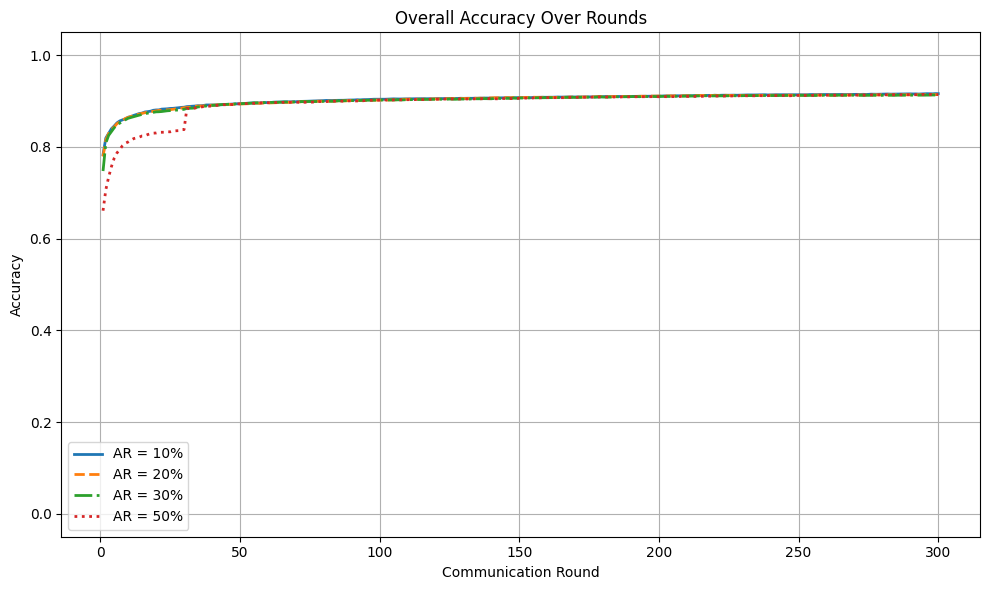

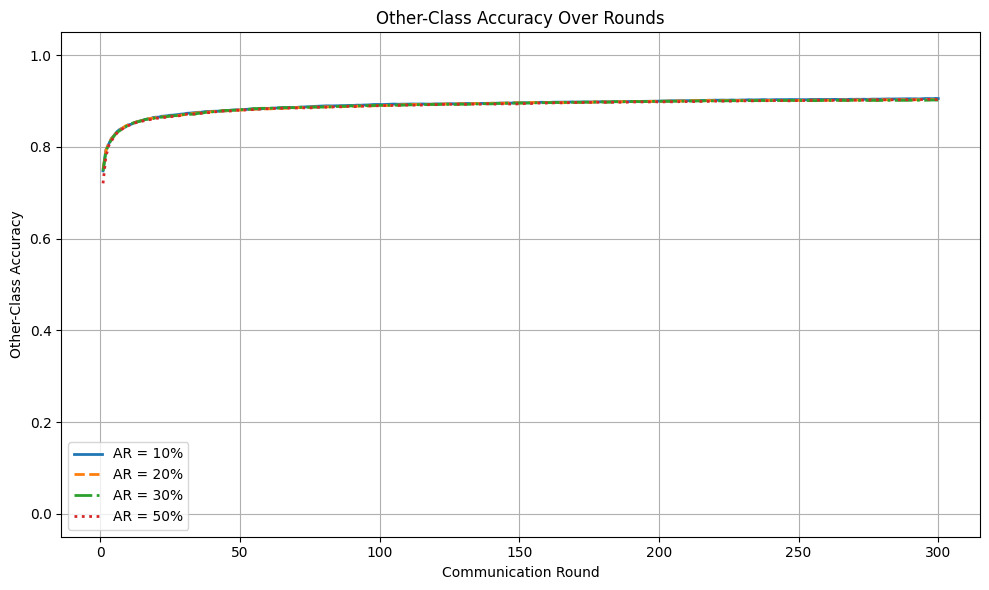

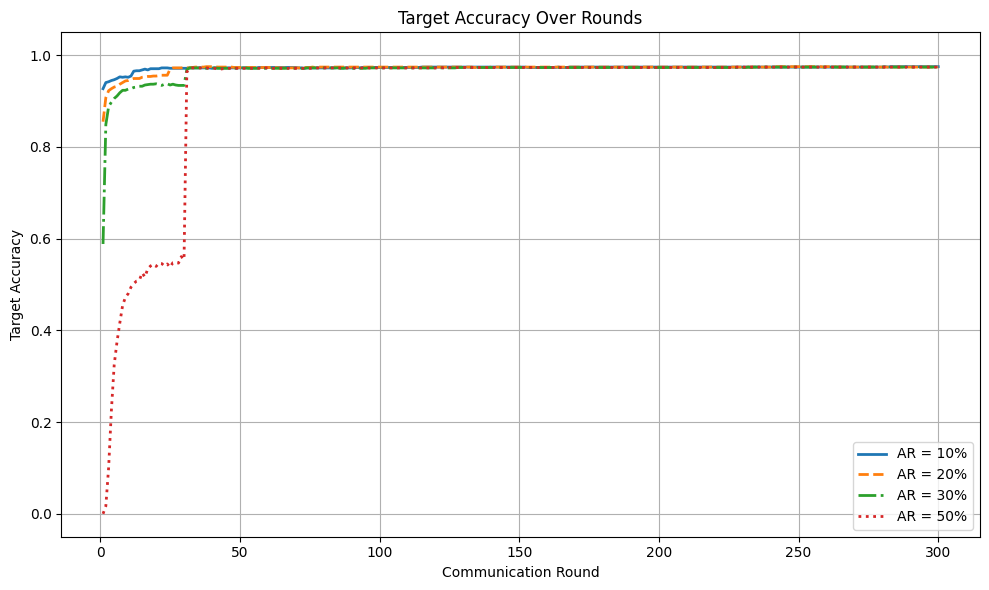


 FINAL RESULTS ACROSS ALL SEEDS

Attack Rate 10%:
  Overall Accuracy : 0.9162 ± 0.0000
  Target Accuracy  : 0.9751 ± 0.0000

Attack Rate 20%:
  Overall Accuracy : 0.9142 ± 0.0000
  Target Accuracy  : 0.9742 ± 0.0000

Attack Rate 30%:
  Overall Accuracy : 0.9132 ± 0.0000
  Target Accuracy  : 0.9742 ± 0.0000

Attack Rate 50%:
  Overall Accuracy : 0.9143 ± 0.0000
  Target Accuracy  : 0.9742 ± 0.0000
